<a href="https://colab.research.google.com/github/sayjinblackbelt/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraude em Transações de Cartão de Crédito

## Objetivo

Este projeto desenvolve um modelo de Machine Learning para detectar transações fraudulentas em uma base de cartões de crédito.

O principal desafio é o forte desbalanceamento das classes: a grande maioria das transações é legítima, enquanto uma pequena parcela representa fraude.

Por isso, a avaliação dos modelos será baseada principalmente em métricas como **recall, precisão e F1-score**, em vez de utilizar apenas acurácia.

## Pipeline

1. Exploração dos dados
2. Preparação e transformação das variáveis
3. Tratamento do desbalanceamento
4. Treinamento dos modelos
5. Avaliação
6. Ajuste do limiar de decisão
7. Comparação dos modelos
8. Explicabilidade com SHAP

In [141]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [142]:
df.shape

(284807, 31)

In [143]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [144]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [145]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [146]:
df["PredicaoIngenua"] = 0

df["PredicaoIngenua"].value_counts()

,count
PredicaoIngenua,
0,284807


In [147]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df["Class"],
    df["PredicaoIngenua"]
)

accuracy

0.9982725143693799

## Por que a acurácia engana?

A base apresenta um forte desbalanceamento entre as classes:

- 99,83% das transações são legítimas;
- 0,17% são fraudulentas.

Como demonstração, foi criado um classificador ingênuo que classifica todas as transações como normais (`Class = 0`).

Esse classificador alcança aproximadamente 99,83% de acurácia, mas não identifica nenhuma das 492 fraudes existentes.

Isso demonstra que a acurácia, isoladamente, não é uma métrica adequada para avaliar o desempenho de um modelo neste problema. A partir daqui, a análise dará maior atenção ao desempenho sobre a classe de fraude, especialmente recall, precisão e F1-score.

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Time             284807 non-null  float64
 1   V1               284807 non-null  float64
 2   V2               284807 non-null  float64
 3   V3               284807 non-null  float64
 4   V4               284807 non-null  float64
 5   V5               284807 non-null  float64
 6   V6               284807 non-null  float64
 7   V7               284807 non-null  float64
 8   V8               284807 non-null  float64
 9   V9               284807 non-null  float64
 10  V10              284807 non-null  float64
 11  V11              284807 non-null  float64
 12  V12              284807 non-null  float64
 13  V13              284807 non-null  float64
 14  V14              284807 non-null  float64
 15  V15              284807 non-null  float64
 16  V16              284807 non-null  floa

In [149]:
df.shape

(284807, 32)

In [150]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'PredicaoIngenua'],
      dtype='object')

In [151]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,PredicaoIngenua
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.0
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727,0.0
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527,0.0
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000,0.0
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000,0.0
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000,0.0
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000,0.0
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000,0.0


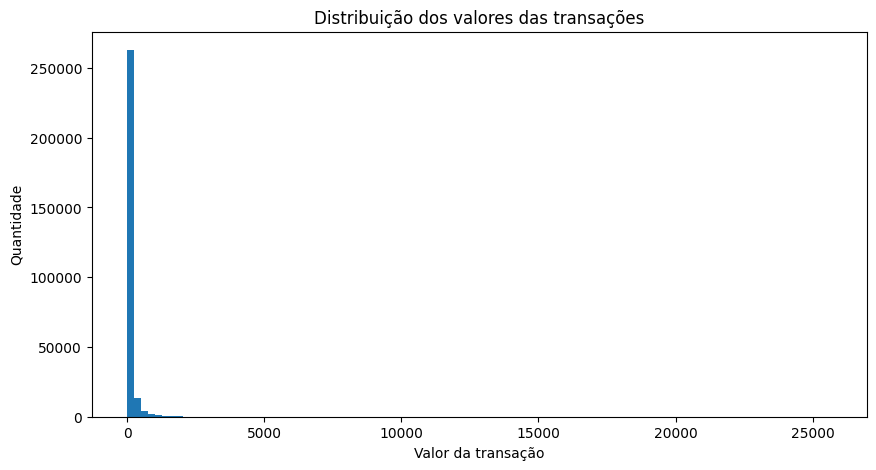

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["Amount"], bins=100)
plt.xlabel("Valor da transação")
plt.ylabel("Quantidade")
plt.title("Distribuição dos valores das transações")
plt.show()

In [153]:
import numpy as np

df["LogAmount"] = np.log1p(df["Amount"])

In [154]:
df[["Amount", "LogAmount"]].describe()

,Amount,LogAmount
count,284807.000000,284807.000000
mean,88.349619,3.152188
std,250.120109,1.656648
min,0.000000,0.000000
25%,5.600000,1.887070
50%,22.000000,3.135494
75%,77.165000,4.358822
max,25691.160000,10.153941


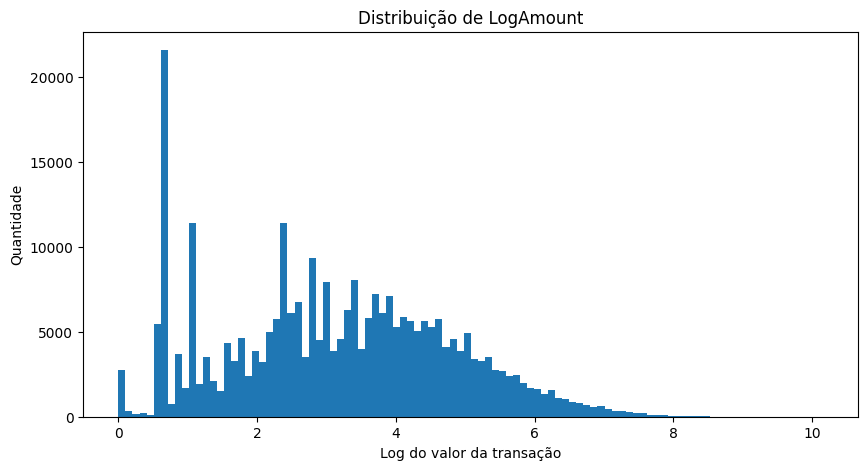

In [155]:
plt.figure(figsize=(10, 5))
plt.hist(df["LogAmount"], bins=100)
plt.xlabel("Log do valor da transação")
plt.ylabel("Quantidade")
plt.title("Distribuição de LogAmount")
plt.show()

In [156]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [157]:
X.shape, y.shape

((284807, 32), (284807,))

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [159]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nFraudes no treino:", y_train.sum())
print("Fraudes no teste:", y_test.sum())


Treino: (227845, 32)
Teste: (56962, 32)

Fraudes no treino: 394
Fraudes no teste: 98


In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [161]:
X_train_scaled.shape, X_test_scaled.shape

((227845, 32), (56962, 32))

In [162]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [163]:
y_pred_logistico = modelo_logistico.predict(X_test_scaled)

In [164]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistico))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [165]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistico)

cm

array([[55483,  1381],
       [    8,    90]])

In [166]:
y_prob_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

y_prob_logistico[:10]

array([5.98137979e-03, 6.49336666e-02, 1.38518057e-04, 1.38013260e-02,
       9.44196204e-01, 1.31316677e-02, 7.76570036e-04, 2.60728950e-02,
       6.51964159e-02, 4.63467441e-03])

In [167]:
from sklearn.metrics import precision_score, recall_score, f1_score

limiar = 0.3

y_pred_030 = (y_prob_logistico >= limiar).astype(int)

print("Limiar:", limiar)
print("Precisão:", precision_score(y_test, y_pred_030))
print("Recall:", recall_score(y_test, y_pred_030))
print("F1:", f1_score(y_test, y_pred_030))

Limiar: 0.3
Precisão: 0.02718212020537602
Recall: 0.9183673469387755
F1: 0.05280140803754767


In [168]:
limiares = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

resultados_limiar = []

for limiar in limiares:
    y_pred = (y_prob_logistico >= limiar).astype(int)

    resultados_limiar.append({
        "Limiar": limiar,
        "Precisao": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

df_limiares = pd.DataFrame(resultados_limiar)

df_limiares

,Limiar,Precisao,Recall,F1
0,0.1,0.008105,0.948980,0.016073
1,0.2,0.016379,0.948980,0.032202
2,0.3,0.027182,0.918367,0.052801
3,0.4,0.042194,0.918367,0.080681
4,0.5,0.061183,0.918367,0.114723
5,0.6,0.087426,0.908163,0.159498
6,0.7,0.124128,0.908163,0.218405
7,0.8,0.162063,0.897959,0.274571
8,0.9,0.247863,0.887755,0.387528


## Ajuste do limiar de decisão

A regressão logística utiliza um limiar padrão de 0,5 para transformar as probabilidades em classes. Como o problema possui forte desbalanceamento, foram testados diferentes limiares.

A redução do limiar aumentou o recall em alguns pontos, mas também reduziu significativamente a precisão. Por outro lado, limiares mais altos aumentaram a precisão e o F1-score, acompanhados por uma redução gradual do recall.

No conjunto de teste, o maior F1 observado entre os limiares testados ocorreu em 0,90, com precisão de aproximadamente 24,8%, recall de 88,8% e F1 de 38,8%.

A escolha definitiva do limiar será analisada em conjunto com os demais modelos e considerando o trade-off entre detecção de fraudes e falsos positivos.

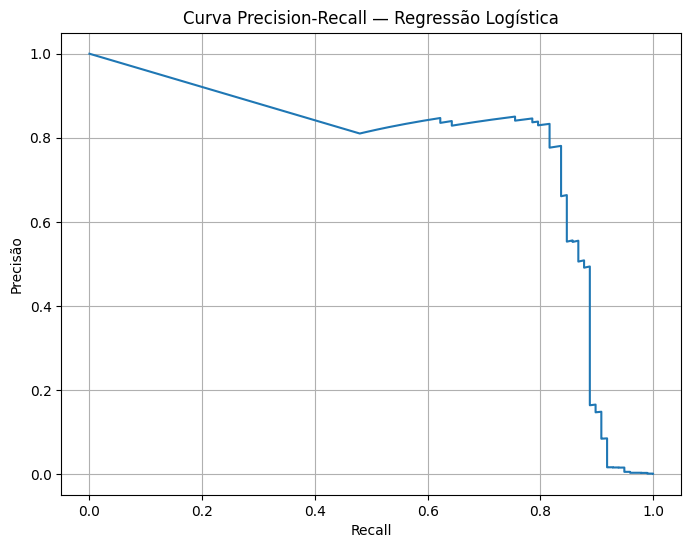

Average Precision: 0.7194303169083883


In [169]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_logistico
)

average_precision = average_precision_score(
    y_test,
    y_prob_logistico
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — Regressão Logística")
plt.grid()
plt.show()

print("Average Precision:", average_precision)

In [170]:
print("Average Precision:", average_precision)

Average Precision: 0.7194303169083883


### Curva Precision-Recall

A curva Precision-Recall foi utilizada para analisar o comportamento da regressão logística em diferentes limiares de decisão.

O modelo apresentou Average Precision (AP) de aproximadamente 0,7194. Essa métrica resume o desempenho ao longo da curva Precision-Recall e é especialmente relevante em um problema com forte desbalanceamento.

O resultado também evidencia que a escolha do limiar altera significativamente o equilíbrio entre precisão e recall. Portanto, a avaliação não deve depender de um único limiar ou somente da acurácia.

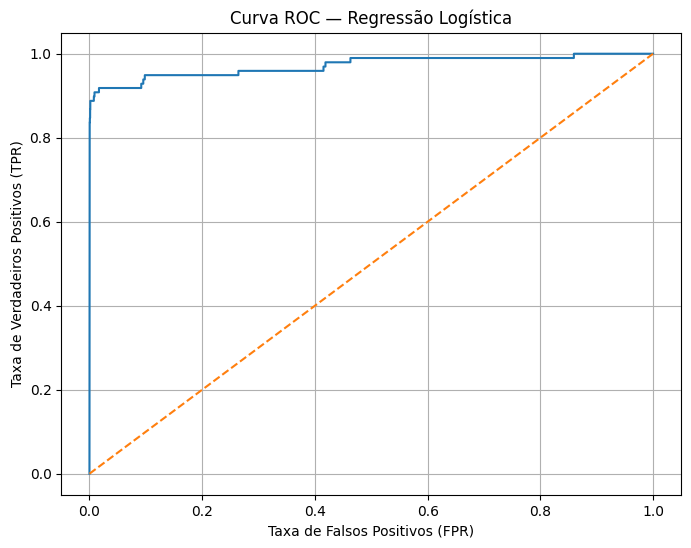

ROC-AUC: 0.9718520128225742


In [171]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob_logistico
)

auc_roc = roc_auc_score(
    y_test,
    y_prob_logistico
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC — Regressão Logística")
plt.grid()
plt.show()

print("ROC-AUC:", auc_roc)

In [172]:
print("ROC-AUC:", auc_roc)

ROC-AUC: 0.9718520128225742


In [109]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [110]:
y_prob_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

In [111]:
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

In [112]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.76      0.84        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [113]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Average Precision:", average_precision_score(y_test, y_prob_rf))

ROC-AUC: 0.9574452793920044
Average Precision: 0.8699214988153159


In [114]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[56860,     4],
       [   24,    74]])

In [115]:
limiares_rf = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

resultados_rf = []

for limiar in limiares_rf:
    y_pred = (y_prob_rf >= limiar).astype(int)

    resultados_rf.append({
        "Limiar": limiar,
        "Precisao": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

df_limiares_rf = pd.DataFrame(resultados_rf)

df_limiares_rf

,Limiar,Precisao,Recall,F1
0,0.1,0.750000,0.887755,0.813084
1,0.2,0.864583,0.846939,0.855670
2,0.3,0.942529,0.836735,0.886486
3,0.4,0.951220,0.795918,0.866667
4,0.5,0.948718,0.755102,0.840909
5,0.6,0.958333,0.704082,0.811765
6,0.7,0.970149,0.663265,0.787879
7,0.8,0.964912,0.561224,0.709677
8,0.9,0.978723,0.469388,0.634483


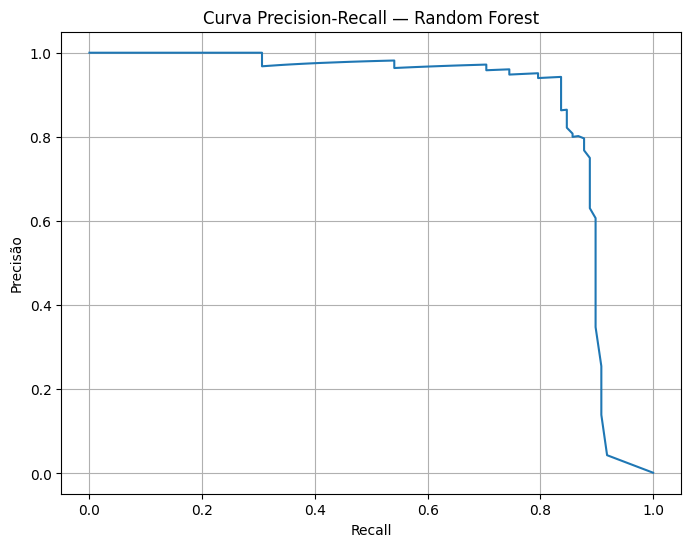

Average Precision: 0.8699214988153159


In [116]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test,
    y_prob_rf
)

average_precision_rf = average_precision_score(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf)
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — Random Forest")
plt.grid()
plt.show()

print("Average Precision:", average_precision_rf)

## Comparação inicial dos modelos

Os resultados abaixo resumem o desempenho obtido até esta etapa do projeto. Para a comparação, são consideradas principalmente as métricas da classe fraude, além de ROC-AUC e Average Precision.

| Modelo | Limiar | Precisão | Recall | F1 | ROC-AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|
| Regressão Logística | 0,50 | 6,12% | 91,84% | 11,47% | 0,9719 | 0,7194 |
| Random Forest | 0,50 | 96,10% | 75,51% | 84,57% | 0,9523 | 0,8666 |
| Random Forest | 0,30 | 94,19% | 82,65% | 88,04% | — | — |

### Observação

A alteração do limiar do Random Forest de 0,50 para 0,30 aumentou o recall de 75,51% para 82,65%, com redução da precisão de 96,10% para 94,19%. O F1-score passou de 84,57% para 88,04%.

Os valores de ROC-AUC e Average Precision apresentados para o Random Forest correspondem à avaliação baseada nas probabilidades produzidas pelo modelo, independentemente do limiar específico utilizado para gerar as classes.

In [117]:
peso_fraude = (y_train == 0).sum() / (y_train == 1).sum()

print("Peso da classe fraude:", peso_fraude)

Peso da classe fraude: 577.2868020304569


In [118]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=peso_fraude,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [119]:
y_prob_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

In [120]:
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

In [121]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.21      0.90      0.34        98

    accuracy                           0.99     56962
   macro avg       0.60      0.95      0.67     56962
weighted avg       1.00      0.99      1.00     56962



In [122]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Average Precision:", average_precision_score(y_test, y_prob_xgb))

ROC-AUC: 0.9787234023463071
Average Precision: 0.6546716276270083


In [123]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_xgb

array([[56525,   339],
       [   10,    88]])

In [124]:
limiares_xgb = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

resultados_xgb = []

for limiar in limiares_xgb:
    y_pred = (y_prob_xgb >= limiar).astype(int)

    resultados_xgb.append({
        "Limiar": limiar,
        "Precisao": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

df_limiares_xgb = pd.DataFrame(resultados_xgb)

df_limiares_xgb

,Limiar,Precisao,Recall,F1
0,0.1,0.023256,0.938776,0.045387
1,0.2,0.050251,0.918367,0.095289
2,0.3,0.089197,0.918367,0.162602
3,0.4,0.141046,0.908163,0.244170
4,0.5,0.206089,0.897959,0.335238
5,0.6,0.282392,0.867347,0.426065
6,0.7,0.386364,0.867347,0.534591
7,0.8,0.521739,0.857143,0.648649
8,0.9,0.725664,0.836735,0.777251


## Ajuste do limiar — XGBoost

O ajuste do limiar altera o equilíbrio entre precisão e recall. Com limiares baixos, o XGBoost identifica uma parcela maior das fraudes, porém gera muitos falsos positivos. Conforme o limiar aumenta, a precisão melhora e o recall diminui.

Entre os limiares testados, 0,90 apresentou o maior F1-score (0,7489), com precisão de 67,77% e recall de 83,67%. Esse resultado será considerado na comparação dos modelos, sem tratá-lo ainda como o limiar definitivo, pois a escolha final deve ser feita sobre dados de validação.

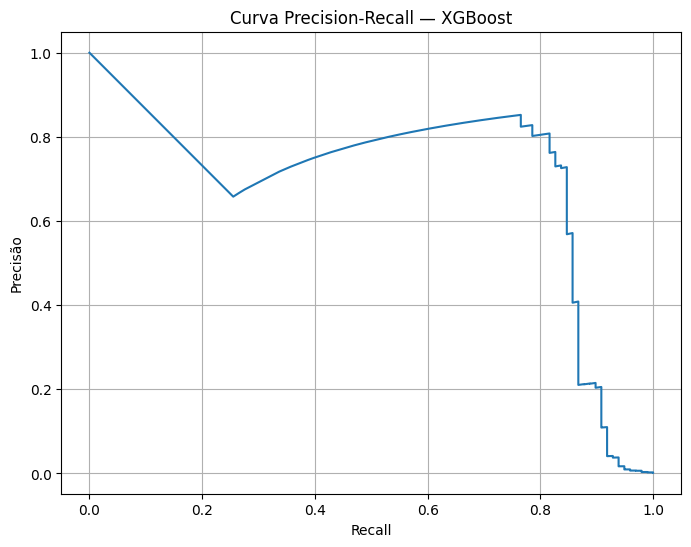

Average Precision: 0.6546716276270083


In [125]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test,
    y_prob_xgb
)

average_precision_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb)

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — XGBoost")
plt.grid()

plt.show()

print("Average Precision:", average_precision_xgb)

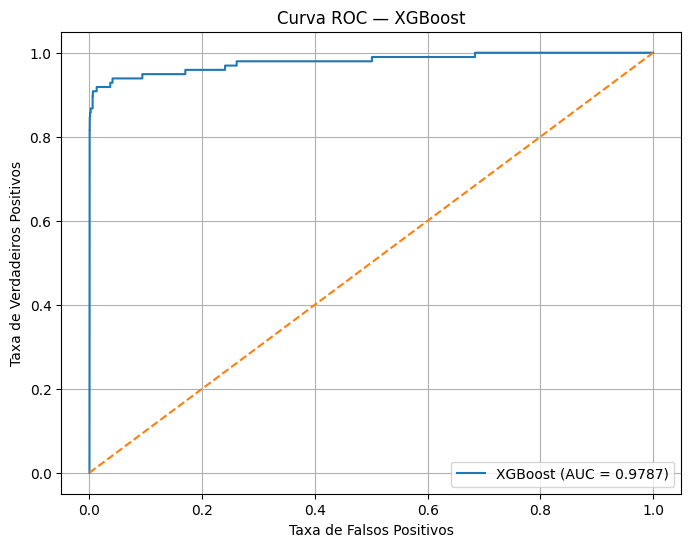

ROC-AUC: 0.9787234023463071


In [126]:
fpr_xgb, tpr_xgb, thresholds_roc_xgb = roc_curve(
    y_test,
    y_prob_xgb
)

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC — XGBoost")
plt.legend()
plt.grid()

plt.show()

print("ROC-AUC:", roc_auc_xgb)

## Comparação dos modelos

Os modelos foram comparados principalmente pelas métricas da classe fraude (classe 1).
Como o problema é altamente desbalanceado, a acurácia não é utilizada como principal critério de avaliação.

Além das métricas em um limiar específico, foram analisadas as curvas ROC e Precision-Recall.

In [127]:
comparacao = pd.DataFrame([
    {
        "Modelo": "Regressão Logística",
        "Limiar": 0.50,
        "Precisão": 0.061183,
        "Recall": 0.918367,
        "F1": 0.114723,
        "ROC-AUC": 0.971852,
        "Average Precision": 0.719430
    },
    {
        "Modelo": "Random Forest",
        "Limiar": 0.30,
        "Precisão": 0.941860,
        "Recall": 0.826531,
        "F1": 0.880435,
        "ROC-AUC": 0.952297,
        "Average Precision": 0.866645
    },
    {
        "Modelo": "XGBoost",
        "Limiar": 0.90,
        "Precisão": 0.677686,
        "Recall": 0.836735,
        "F1": 0.748858,
        "ROC-AUC": 0.979954,
        "Average Precision": 0.685835
    }
])

comparacao

,Modelo,Limiar,Precisão,Recall,F1,ROC-AUC,Average Precision
0,Regressão Logística,0.5,0.061183,0.918367,0.114723,0.971852,0.719430
1,Random Forest,0.3,0.941860,0.826531,0.880435,0.952297,0.866645
2,XGBoost,0.9,0.677686,0.836735,0.748858,0.979954,0.685835


In [128]:
!pip install -q shap

In [129]:
import shap

In [130]:
explainer = shap.TreeExplainer(modelo_xgb)

In [131]:
import shap
import numpy as np

explainer = shap.TreeExplainer(modelo_xgb)

np.random.seed(42)

indices_shap = np.random.choice(
    len(X_test_scaled),
    size=min(2000, len(X_test_scaled)),
    replace=False
)

X_shap = X_test_scaled[indices_shap]

shap_values = explainer.shap_values(X_shap)

In [132]:
feature_names = X.columns.tolist()

print(len(feature_names))
print(X_shap.shape)

32
(2000, 32)


/tmp/ipykernel_1362/102913372.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


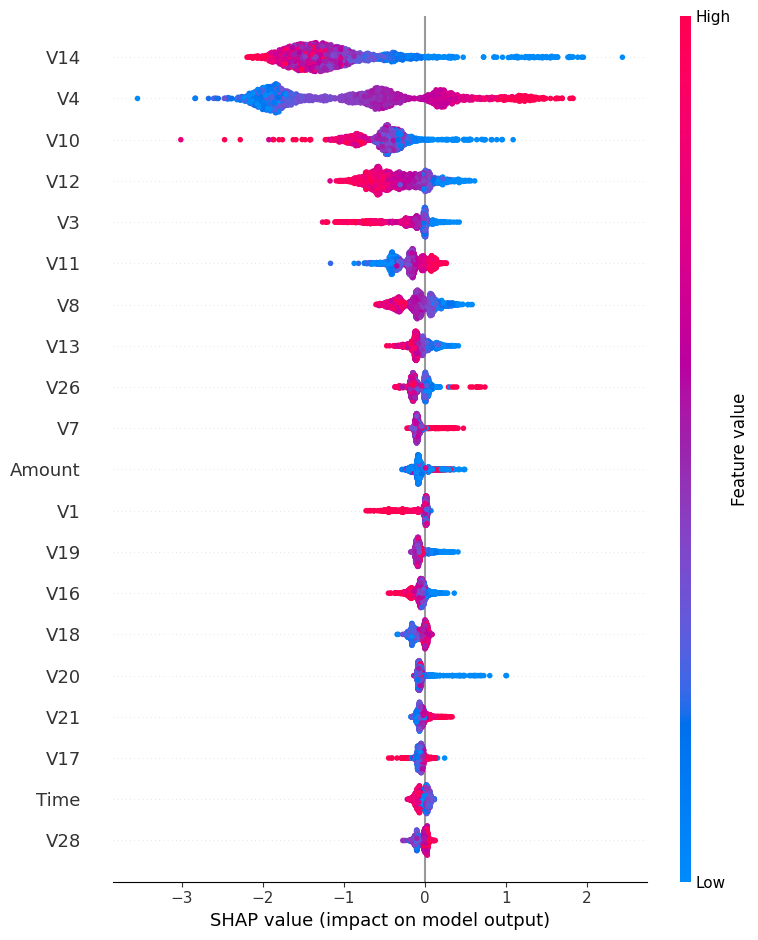

In [133]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

## Explicabilidade com SHAP

O SHAP foi utilizado para interpretar as decisões do XGBoost.

Na análise global, as variáveis com maior influência média nas decisões do modelo foram V14, V4, V10, V12, V3, V11, V8, V7, V26 e Amount.

O gráfico também permite observar a direção da contribuição de cada variável. Por exemplo, valores baixos de V14 aparecem associados a contribuições SHAP positivas, enquanto valores altos de V14 aparecem predominantemente associados a contribuições negativas. Para V4, observa-se uma tendência oposta.

As variáveis V1 a V28 são componentes transformadas por PCA. Portanto, sua importância pode ser utilizada para explicar o comportamento do modelo, mas não permite atribuir diretamente um significado de negócio original a cada componente.

In [134]:
y_test_array = np.asarray(y_test)

candidatos = np.where(
    (y_test_array == 1) &
    (y_prob_xgb >= 0.90)
)[0]

print("Fraudes reais classificadas com probabilidade >= 0.90:", len(candidatos))

Fraudes reais classificadas com probabilidade >= 0.90: 82


In [135]:
idx_local = candidatos[np.argmax(y_prob_xgb[candidatos])]

print("Posição no conjunto de teste:", idx_local)
print("Probabilidade de fraude:", y_prob_xgb[idx_local])
print("Classe real:", y_test_array[idx_local])

Posição no conjunto de teste: 1146
Probabilidade de fraude: 0.9960075
Classe real: 1


In [136]:
X_individual = X_test_scaled[idx_local:idx_local+1]

print(X_individual.shape)

(1, 32)


In [137]:
shap_individual = explainer.shap_values(X_individual)

print(shap_individual.shape)

(1, 32)


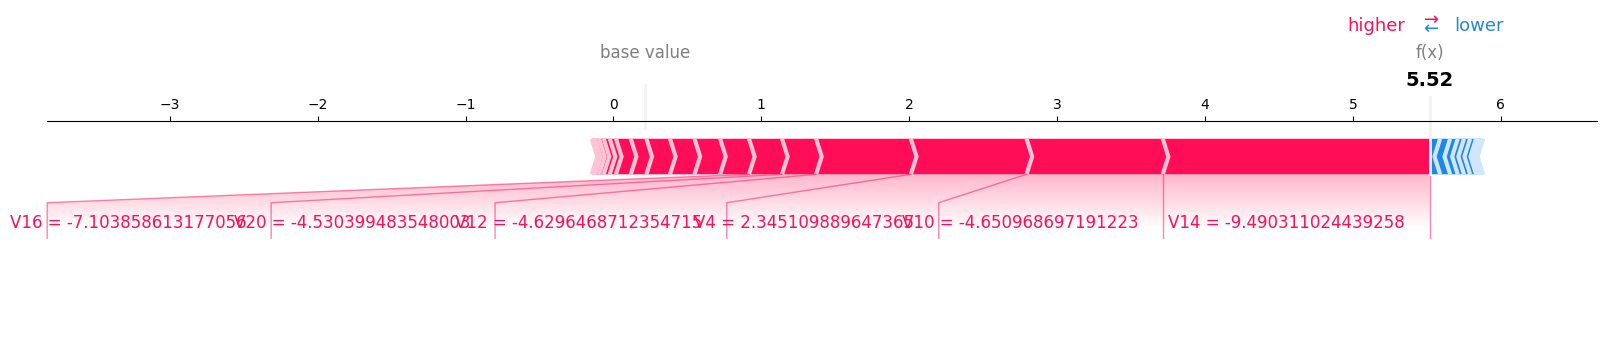

In [138]:
shap.force_plot(
    explainer.expected_value,
    shap_individual[0],
    X_individual[0],
    feature_names=feature_names,
    matplotlib=True
)

## Explicação de uma transação individual

Além da análise global, o SHAP foi utilizado para explicar uma transação específica classificada pelo modelo.

A explicação individual mostra como diferentes variáveis contribuíram para aumentar ou diminuir a saída do modelo. As contribuições positivas empurram a previsão para uma saída maior, enquanto as contribuições negativas exercem o efeito contrário.

Nesta transação, variáveis como V14, V19, V10, V12 e V11 apresentaram contribuições relevantes para a decisão.

A saída `f(x)` apresentada pelo gráfico SHAP representa a saída do modelo utilizada pelo explicador e não deve ser interpretada diretamente como uma probabilidade de fraude.

In [139]:
print("Índice:", idx_local)
print("Classe real:", y_test_array[idx_local])
print("Probabilidade de fraude:", y_prob_xgb[idx_local])

Índice: 1146
Classe real: 1
Probabilidade de fraude: 0.9960075


In [140]:
print("Previsão com limiar 0.90:", int(y_prob_xgb[idx_local] >= 0.90))

Previsão com limiar 0.90: 1


### Exemplo de explicação individual

Foi analisada uma transação real de fraude localizada na posição 3287 do conjunto de teste.

- Classe real: 1 (fraude)
- Probabilidade estimada pelo XGBoost: 0.9964
- Limiar de decisão analisado: 0.90
- Previsão: 1 (fraude)

O SHAP permite observar quais variáveis contribuíram para aumentar ou reduzir a saída do modelo nessa decisão específica. As contribuições não representam causalidade nem significam que uma determinada variável seja, por si só, responsável pela fraude.